Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

pd.set_option("display.max_columns", None)

Load cleaned data

In [2]:
df = pd.read_csv(
    "../data/processed/telco_churn_clean.csv"
)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 22)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-6 months
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25-36 months
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-6 months
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37-48 months
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-6 months


Prepare target

In [3]:
X = df.drop(columns=["Churn", "customerID"])

y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print((y.value_counts(normalize=True) * 100).round(2))

Feature shape: (7043, 20)
Target shape: (7043,)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Target percentage:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


Train/test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining churn rate:")
print(y_train.mean().round(4))

print("\nTest churn rate:")
print(y_test.mean().round(4))

Training set: (5634, 20)
Test set: (1409, 20)

Training churn rate:
0.2654

Test churn rate:
0.2654


Prepare feature types

In [5]:
# Remove the derived tenure grouping
X_train = X_train.drop(columns=["TenureGroup"])
X_test = X_test.drop(columns=["TenureGroup"])

numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    col for col in X_train.columns
    if col not in numeric_features
]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Numeric features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Number of numeric features: 4
Number of categorical features: 15


Build preprocessing pipeline

In [6]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


First baseline model

In [7]:
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

baseline_model.fit(X_train, y_train)

print("Baseline Logistic Regression trained successfully.")

Baseline Logistic Regression trained successfully.


In [8]:
y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

print("===== BASELINE LOGISTIC REGRESSION =====")

print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1:", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

===== BASELINE LOGISTIC REGRESSION =====
Precision: 0.6604
Recall: 0.5615
F1: 0.6069
ROC-AUC: 0.8422
PR-AUC: 0.635

Confusion Matrix:
[[927 108]
 [164 210]]


In [10]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


Reload and prepare the data

In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

from xgboost import XGBClassifier

# Load cleaned dataset
df = pd.read_csv(
    "../data/processed/telco_churn_clean.csv"
)

# Target and features
X = df.drop(columns=["Churn", "customerID", "TenureGroup"])

y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Feature types
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    col for col in X.columns
    if col not in numeric_features
]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("Churn rate:", round(y_train.mean(), 4))

Training set: (5634, 19)
Test set: (1409, 19)
Churn rate: 0.2654


Build the preprocessing pipeline

In [12]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


Train XGBoost

In [13]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


Evaluate XGBoost

In [14]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(
    X_test
)[:, 1]

print("===== XGBOOST =====")

print(
    "Precision:",
    round(precision_score(y_test, y_pred_xgb), 4)
)

print(
    "Recall:",
    round(recall_score(y_test, y_pred_xgb), 4)
)

print(
    "F1:",
    round(f1_score(y_test, y_pred_xgb), 4)
)

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, y_prob_xgb), 4)
)

print(
    "PR-AUC:",
    round(average_precision_score(y_test, y_prob_xgb), 4)
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

===== XGBOOST =====
Precision: 0.6644
Recall: 0.5294
F1: 0.5893
ROC-AUC: 0.8399
PR-AUC: 0.6544

Confusion Matrix:
[[935 100]
 [176 198]]


Tune the XGBoost threshold

In [15]:
thresholds = np.arange(0.20, 0.71, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_xgb >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results.round(4)

,Threshold,Precision,Recall,F1
0,0.20,0.4734,0.8316,0.6033
1,0.25,0.5025,0.7941,0.6155
2,0.30,0.5260,0.7567,0.6206
3,0.35,0.5456,0.7032,0.6145
4,0.40,0.5875,0.6551,0.6195
5,0.45,0.6120,0.5989,0.6054
6,0.50,0.6644,0.5294,0.5893
7,0.55,0.6932,0.4652,0.5568
8,0.60,0.7259,0.3824,0.5009
9,0.65,0.7375,0.3155,0.4419


In [17]:
import matplotlib.pyplot as plt

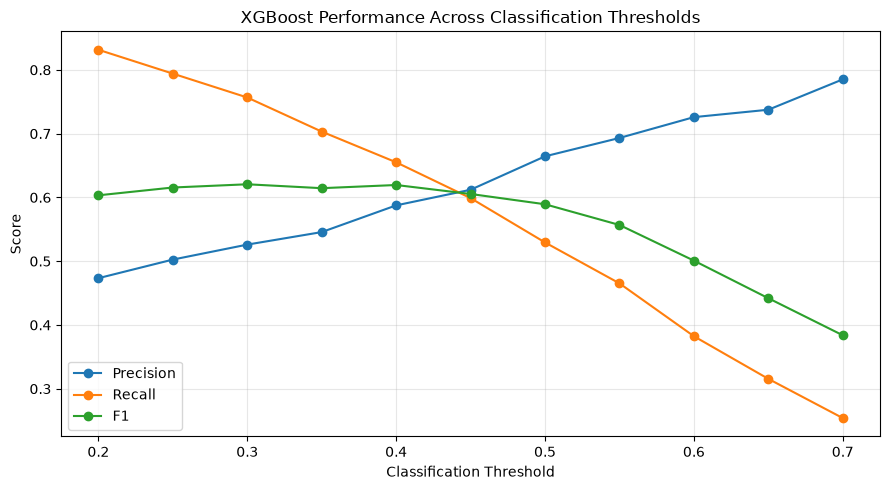

In [18]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("XGBoost Performance Across Classification Thresholds")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Calculate confusion matrices at important thresholds

In [19]:
selected_thresholds = [0.30, 0.40, 0.50]

threshold_comparison = []

for threshold in selected_thresholds:

    predictions = (
        y_prob_xgb >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    threshold_comparison.append({
        "Threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Precision": precision_score(
            y_test,
            predictions
        ),
        "Recall": recall_score(
            y_test,
            predictions
        ),
        "F1": f1_score(
            y_test,
            predictions
        )
    })

threshold_comparison = pd.DataFrame(
    threshold_comparison
)

threshold_comparison.round(4)

,Threshold,TN,FP,FN,TP,Precision,Recall,F1
0,0.3,780,255,91,283,0.5260,0.7567,0.6206
1,0.4,863,172,129,245,0.5875,0.6551,0.6195
2,0.5,935,100,176,198,0.6644,0.5294,0.5893


business-cost analysis

In [20]:
cost_fn = 100   # Cost of missing a churner
cost_fp = 10    # Cost of contacting a non-churner

cost_results = []

for threshold in thresholds:

    predictions = (
        y_prob_xgb >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    total_cost = (
        fn * cost_fn +
        fp * cost_fp
    )

    cost_results.append({
        "Threshold": threshold,
        "FP": fp,
        "FN": fn,
        "TotalCost": total_cost
    })

cost_results = pd.DataFrame(cost_results)

cost_results.sort_values(
    "TotalCost"
).round(2)

,Threshold,FP,FN,TotalCost
0,0.20,346,63,9760
1,0.25,294,77,10640
2,0.30,255,91,11650
3,0.35,219,111,13290
4,0.40,172,129,14620
5,0.45,142,150,16420
6,0.50,100,176,18600
7,0.55,77,200,20770
8,0.60,54,231,23640
9,0.65,42,256,26020


In [21]:
cost_scenarios = [
    {"Scenario": "Balanced", "FN_Cost": 50, "FP_Cost": 10},
    {"Scenario": "Moderate", "FN_Cost": 100, "FP_Cost": 10},
    {"Scenario": "High Churn Cost", "FN_Cost": 200, "FP_Cost": 10},
    {"Scenario": "Very High Churn Cost", "FN_Cost": 500, "FP_Cost": 10},
]

scenario_results = []

for scenario in cost_scenarios:

    for threshold in thresholds:

        predictions = (
            y_prob_xgb >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_test,
            predictions
        ).ravel()

        total_cost = (
            fn * scenario["FN_Cost"]
            + fp * scenario["FP_Cost"]
        )

        scenario_results.append({
            "Scenario": scenario["Scenario"],
            "Threshold": threshold,
            "FP": fp,
            "FN": fn,
            "TotalCost": total_cost
        })

scenario_results = pd.DataFrame(
    scenario_results
)

scenario_results.loc[
    scenario_results.groupby("Scenario")["TotalCost"].idxmin()
].sort_values("Scenario")

,Scenario,Threshold,FP,FN,TotalCost
0,Balanced,0.2,346,63,6610
22,High Churn Cost,0.2,346,63,16060
11,Moderate,0.2,346,63,9760
33,Very High Churn Cost,0.2,346,63,34960


final XGBoost metrics at 0.20

In [22]:
final_threshold = 0.20

y_pred_final = (
    y_prob_xgb >= final_threshold
).astype(int)

print("XGBoost at threshold =", final_threshold)
print()

print("Precision:",
      round(precision_score(y_test, y_pred_final), 4))

print("Recall:",
      round(recall_score(y_test, y_pred_final), 4))

print("F1:",
      round(f1_score(y_test, y_pred_final), 4))

print("ROC-AUC:",
      round(roc_auc_score(y_test, y_prob_xgb), 4))

print("PR-AUC:",
      round(average_precision_score(y_test, y_prob_xgb), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

XGBoost at threshold = 0.2

Precision: 0.4734
Recall: 0.8316
F1: 0.6033
ROC-AUC: 0.8399
PR-AUC: 0.6544

Confusion Matrix:
[[689 346]
 [ 63 311]]


Import SHAP and extract XGBoost

In [23]:
import shap

# Extract the fitted preprocessing pipeline
fitted_preprocessor = xgb_model.named_steps["preprocessor"]

# Extract the fitted XGBoost classifier
fitted_xgb = xgb_model.named_steps["classifier"]

print("SHAP version:", shap.__version__)
print("XGBoost model extracted successfully.")

SHAP version: 0.52.0
XGBoost model extracted successfully.


Transform the test data

In [24]:
X_test_transformed = fitted_preprocessor.transform(X_test)

print("Transformed test shape:", X_test_transformed.shape)

Transformed test shape: (1409, 30)


Get the transformed feature names

In [25]:
feature_names = fitted_preprocessor.get_feature_names_out()

print("Number of feature names:", len(feature_names))
print(feature_names)

Number of feature names: 30
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'cat__gender_Male' 'cat__Partner_Yes'
 'cat__Dependents_Yes' 'cat__PhoneService_Yes'
 'cat__MultipleLines_No phone service' 'cat__MultipleLines_Yes'
 'cat__InternetService_Fiber optic' 'cat__InternetService_No'
 'cat__OnlineSecurity_No internet service' 'cat__OnlineSecurity_Yes'
 'cat__OnlineBackup_No internet service' 'cat__OnlineBackup_Yes'
 'cat__DeviceProtection_No internet service' 'cat__DeviceProtection_Yes'
 'cat__TechSupport_No internet service' 'cat__TechSupport_Yes'
 'cat__StreamingTV_No internet service' 'cat__StreamingTV_Yes'
 'cat__StreamingMovies_No internet service' 'cat__StreamingMovies_Yes'
 'cat__Contract_One year' 'cat__Contract_Two year'
 'cat__PaperlessBilling_Yes' 'cat__PaymentMethod_Credit card (automatic)'
 'cat__PaymentMethod_Electronic check' 'cat__PaymentMethod_Mailed check']


Create the SHAP explainer

In [26]:
explainer = shap.TreeExplainer(fitted_xgb)

shap_values = explainer.shap_values(
    X_test_transformed
)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (1409, 30)


Calculate global SHAP importance

In [27]:
shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "MeanAbsSHAP": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "MeanAbsSHAP",
    ascending=False
).reset_index(drop=True)

shap_importance.head(15)

,Feature,MeanAbsSHAP
0,cat__Contract_Two year,0.547296
1,num__tenure,0.537577
2,cat__InternetService_Fiber optic,0.333360
3,num__MonthlyCharges,0.264859
4,cat__Contract_One year,0.251568
5,num__TotalCharges,0.216388
6,cat__PaymentMethod_Electronic check,0.203179
7,cat__PaperlessBilling_Yes,0.142857
8,cat__OnlineSecurity_Yes,0.132113
9,cat__MultipleLines_Yes,0.125220


Make the SHAP feature-importance plot

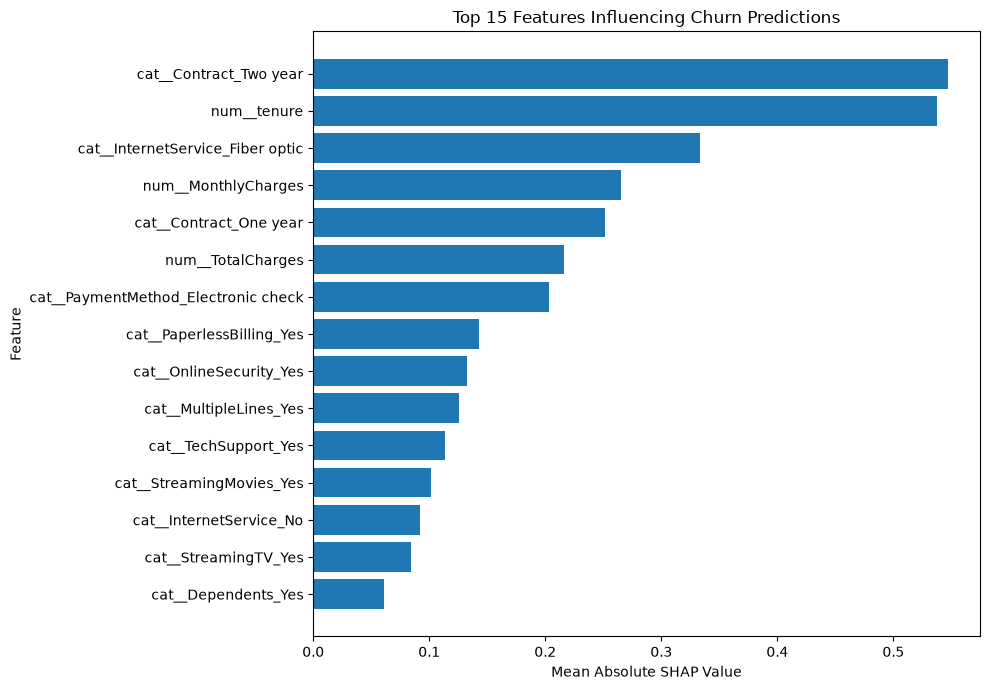

In [28]:
top_features = shap_importance.head(15).sort_values(
    "MeanAbsSHAP"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["MeanAbsSHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 15 Features Influencing Churn Predictions")

plt.tight_layout()
plt.show()

Create a SHAP beeswarm plot

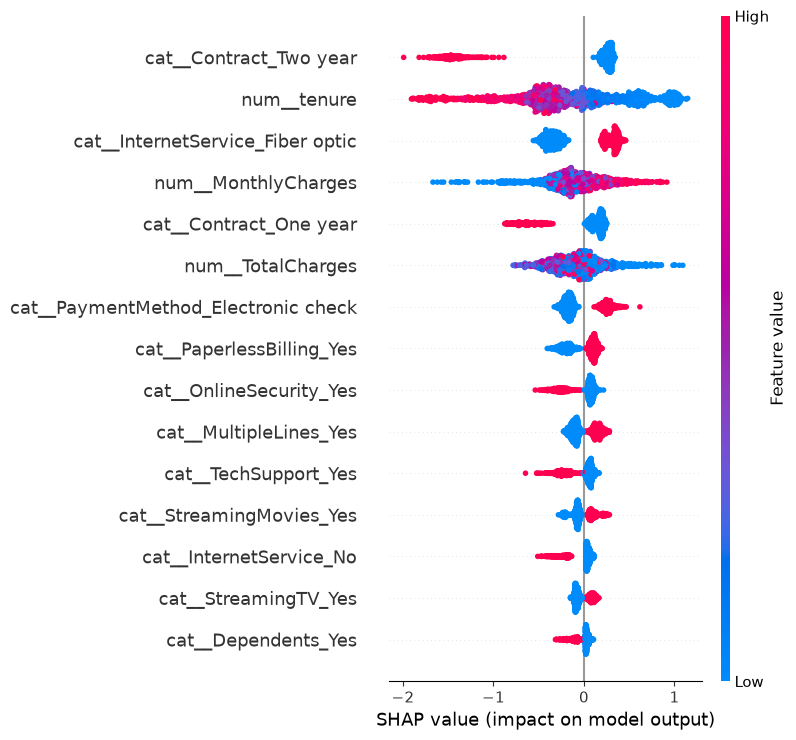

In [29]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    max_display=15
)

Explain an individual customer

In [31]:
customer_values = np.asarray(
    X_test_transformed[customer_index]
).flatten()

customer_explanation = pd.DataFrame({
    "Feature": feature_names,
    "SHAP": shap_values[customer_index],
    "Value": customer_values
})

customer_explanation["AbsSHAP"] = (
    customer_explanation["SHAP"].abs()
)

customer_explanation = customer_explanation.sort_values(
    "AbsSHAP",
    ascending=False
)

customer_explanation.head(10)

,Feature,SHAP,Value,AbsSHAP
25,cat__Contract_Two year,-1.654090,1.000000,1.654090
1,num__tenure,-1.558958,1.608483,1.558958
13,cat__OnlineSecurity_Yes,-0.356669,1.000000,0.356669
6,cat__Dependents_Yes,-0.225894,1.000000,0.225894
10,cat__InternetService_Fiber optic,0.204915,1.000000,0.204915
3,num__TotalCharges,0.200586,2.706828,0.200586
19,cat__TechSupport_Yes,-0.184762,1.000000,0.184762
15,cat__OnlineBackup_Yes,-0.143789,1.000000,0.143789
28,cat__PaymentMethod_Electronic check,-0.141050,0.000000,0.141050
9,cat__MultipleLines_Yes,0.119530,1.000000,0.119530


Generate the SHAP waterfall plot

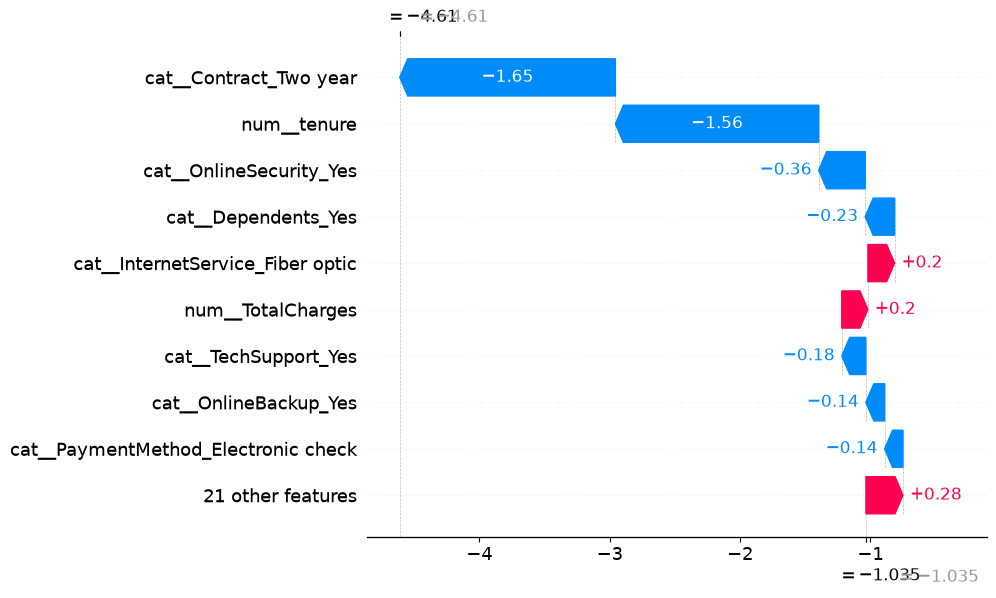

In [32]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[customer_index],
    feature_names=feature_names,
    max_display=10
)

Create a business-friendly customer profile

In [33]:
customer = X_test.iloc[customer_index]

customer

gender                                 Male
SeniorCitizen                             0
Partner                                 Yes
Dependents                              Yes
tenure                                   72
PhoneService                            Yes
MultipleLines                           Yes
InternetService                 Fiber optic
OnlineSecurity                          Yes
OnlineBackup                            Yes
DeviceProtection                        Yes
TechSupport                             Yes
StreamingTV                             Yes
StreamingMovies                         Yes
Contract                           Two year
PaperlessBilling                        Yes
PaymentMethod       Credit card (automatic)
MonthlyCharges                       114.05
TotalCharges                         8468.2
Name: 437, dtype: object

In [34]:
customer_probability = y_prob_xgb[customer_index]

print(
    "Predicted churn probability:",
    round(customer_probability, 4)
)

print(
    "Predicted churn:",
    "Yes" if customer_probability >= 0.20 else "No"
)

Predicted churn probability: 0.0099
Predicted churn: No


Build a clean individual explanation

In [35]:
customer = X_test.iloc[customer_index]

print("Customer profile:")
print(customer)

print("\nPredicted churn probability:",
      round(y_prob_xgb[customer_index], 4))

print(
    "Risk classification:",
    "High Risk" if y_prob_xgb[customer_index] >= 0.20
    else "Low Risk"
)

Customer profile:
gender                                 Male
SeniorCitizen                             0
Partner                                 Yes
Dependents                              Yes
tenure                                   72
PhoneService                            Yes
MultipleLines                           Yes
InternetService                 Fiber optic
OnlineSecurity                          Yes
OnlineBackup                            Yes
DeviceProtection                        Yes
TechSupport                             Yes
StreamingTV                             Yes
StreamingMovies                         Yes
Contract                           Two year
PaperlessBilling                        Yes
PaymentMethod       Credit card (automatic)
MonthlyCharges                       114.05
TotalCharges                         8468.2
Name: 437, dtype: object

Predicted churn probability: 0.0099
Risk classification: Low Risk


Create a clean business explanation table

In [36]:
# Original customer values
customer = X_test.iloc[customer_index]

# Build explanation table
explanation = pd.DataFrame({
    "Feature": feature_names,
    "SHAP": shap_values[customer_index]
})

# Map transformed feature names back to readable names
feature_mapping = {
    "num__SeniorCitizen": "Senior Citizen",
    "num__tenure": "Tenure",
    "num__MonthlyCharges": "Monthly Charges",
    "num__TotalCharges": "Total Charges",
    "cat__gender_Male": "Gender: Male",
    "cat__Partner_Yes": "Partner: Yes",
    "cat__Dependents_Yes": "Dependents: Yes",
    "cat__PhoneService_Yes": "Phone Service: Yes",
    "cat__MultipleLines_No phone service": "Multiple Lines: No phone service",
    "cat__MultipleLines_Yes": "Multiple Lines: Yes",
    "cat__InternetService_Fiber optic": "Internet Service: Fiber optic",
    "cat__InternetService_No": "Internet Service: No",
    "cat__OnlineSecurity_No internet service": "Online Security: No internet service",
    "cat__OnlineSecurity_Yes": "Online Security: Yes",
    "cat__OnlineBackup_No internet service": "Online Backup: No internet service",
    "cat__OnlineBackup_Yes": "Online Backup: Yes",
    "cat__DeviceProtection_No internet service": "Device Protection: No internet service",
    "cat__DeviceProtection_Yes": "Device Protection: Yes",
    "cat__TechSupport_No internet service": "Tech Support: No internet service",
    "cat__TechSupport_Yes": "Tech Support: Yes",
    "cat__StreamingTV_No internet service": "Streaming TV: No internet service",
    "cat__StreamingTV_Yes": "Streaming TV: Yes",
    "cat__StreamingMovies_No internet service": "Streaming Movies: No internet service",
    "cat__StreamingMovies_Yes": "Streaming Movies: Yes",
    "cat__Contract_One year": "Contract: One year",
    "cat__Contract_Two year": "Contract: Two year",
    "cat__PaperlessBilling_Yes": "Paperless Billing: Yes",
    "cat__PaymentMethod_Credit card (automatic)": "Payment: Credit card automatic",
    "cat__PaymentMethod_Electronic check": "Payment: Electronic check",
    "cat__PaymentMethod_Mailed check": "Payment: Mailed check"
}

explanation["Feature"] = explanation["Feature"].map(
    feature_mapping
)

explanation["Direction"] = np.where(
    explanation["SHAP"] > 0,
    "Increases churn risk",
    "Decreases churn risk"
)

explanation["AbsSHAP"] = explanation["SHAP"].abs()

explanation = explanation.sort_values(
    "AbsSHAP",
    ascending=False
)

explanation.head(10)

,Feature,SHAP,Direction,AbsSHAP
25,Contract: Two year,-1.654090,Decreases churn risk,1.654090
1,Tenure,-1.558958,Decreases churn risk,1.558958
13,Online Security: Yes,-0.356669,Decreases churn risk,0.356669
6,Dependents: Yes,-0.225894,Decreases churn risk,0.225894
10,Internet Service: Fiber optic,0.204915,Increases churn risk,0.204915
3,Total Charges,0.200586,Increases churn risk,0.200586
19,Tech Support: Yes,-0.184762,Decreases churn risk,0.184762
15,Online Backup: Yes,-0.143789,Decreases churn risk,0.143789
28,Payment: Electronic check,-0.141050,Decreases churn risk,0.141050
9,Multiple Lines: Yes,0.119530,Increases churn risk,0.119530


Save the model 

In [37]:
import joblib

model_path = "../data/processed/xgb_churn_pipeline.joblib"

joblib.dump(
    xgb_model,
    model_path
)

print("Model saved to:")
print(model_path)

Model saved to:
../data/processed/xgb_churn_pipeline.joblib


Verify the saved model

In [38]:
import os

print(
    "Model exists:",
    os.path.exists(model_path)
)

print(
    "Model size:",
    round(os.path.getsize(model_path) / 1024 / 1024, 2),
    "MB"
)

Model exists: True
Model size: 0.47 MB
